In [12]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
import random

In [21]:
def frame_to_log_intensity(frame):
  gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY).astype(np.float32)
  #log_intensity = np.log1p(gray)
  return np.log(gray + 1e-3)

def generate_events(video_path, threshold=0.10):
  cap = cv2.VideoCapture(video_path)
  ret, prev_frame = cap.read()
  ref_log = frame_to_log_intensity(prev_frame)

  events = []
  t=0

  while True:
    ret, frame = cap.read()
    if not ret:
      break
    t +=1
    curr_log = frame_to_log_intensity(frame)
    diff = curr_log - ref_log


    ys, xs = np.where(np.abs(diff) >= threshold)
    for x, y in zip(xs, ys):
      polarity = 1 if diff[y, x] > 0 else -1
      events.append((x, y, t, polarity))
      ref_log[y, x] = curr_log[y, x]

    cap.release()
    return events

In [22]:
import matplotlib.pyplot as plt

def visualize_events(events, width, height):
    img = np.zeros((height, width, 3), dtype=np.uint8)
    for x, y, t, p in events:
        img[y, x] = [255, 0, 0] if p == 1 else [0, 0, 255]  # ON=লাল, OFF=নীল
    plt.figure(figsize=(8,6))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

Saving 15274086_1920_1080_24fps.mp4 to 15274086_1920_1080_24fps (2).mp4
Width: 1920, Height: 1080, FPS: 24.0, Total frames: 227
মোট 81548 টা event তৈরি হয়েছে


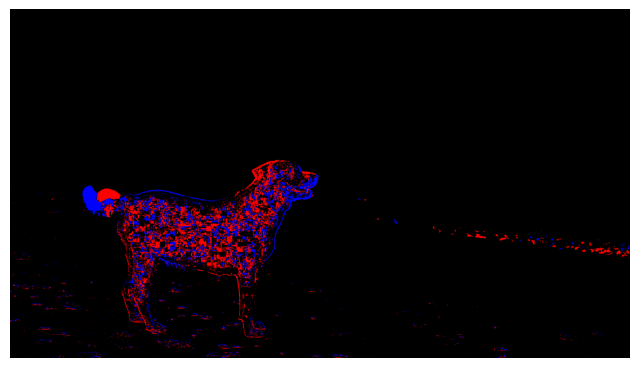

In [23]:
# ধাপ ১: video upload করা
from google.colab import files
uploaded = files.upload()
video_filename = list(uploaded.keys())[0]

# ধাপ ২: video info যাচাই করা (width, height জানা দরকার visualize এর জন্য)
import cv2
cap = cv2.VideoCapture(video_filename)
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps    = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
cap.release()

print(f"Width: {width}, Height: {height}, FPS: {fps}, Total frames: {total_frames}")

# ধাপ ৩: events generate করা
events = generate_events(video_filename, threshold=0.15)
print(f"মোট {len(events)} টা event তৈরি হয়েছে")

# ধাপ ৪: visualize করা
visualize_events(events, width, height)

In [24]:
print(f"মোট event সংখ্যা: {len(events)}")
print(f"প্রথম event: {events[0]}")
print(f"শেষ event: {events[-1]}")

# timestamp গুলোর distribution দেখুন
timestamps = [e[2] for e in events]
print(f"সর্বনিম্ন t: {min(timestamps)}, সর্বোচ্চ t: {max(timestamps)}")

মোট event সংখ্যা: 81548
প্রথম event: (np.int64(0), np.int64(343), 1, -1)
শেষ event: (np.int64(1793), np.int64(1079), 1, -1)
সর্বনিম্ন t: 1, সর্বোচ্চ t: 1


In [25]:
cap = cv2.VideoCapture(video_filename)
print("Video opened successfully:", cap.isOpened())

total_frames_reported = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print(f"Metadata অনুযায়ী total frames: {total_frames_reported}")

# আসলে কয়টা frame সত্যিকারে পড়া যাচ্ছে সেটা গুনুন
count = 0
while True:
    ret, frame = cap.read()
    if not ret:
        break
    count += 1
cap.release()
print(f"আসলে পড়া গেলো: {count} টা frame")

Video opened successfully: True
Metadata অনুযায়ী total frames: 227
আসলে পড়া গেলো: 227 টা frame
